# Setup

## Packages

In [30]:
from preamble import *
from natural_units_GeV import *

from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# import the lens model class 
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
# import the lens equation solver class (finding image plane positions of a source position)
from lenstronomy.LensModel.Solver.lens_equation_solver import LensEquationSolver
# import lens model solver with 4 image positions constraints
from lenstronomy.LensModel.Solver.solver4point import Solver4Point


## Parameters

In [81]:
# B1422+231 parameters from Cosmograil 2012

# distances
z_lens = 0.34
z_source = 3.62

# coordinates of images and galaxy/group
coord_ref = SkyCoord('14h24m38.09s', '+22d56m00.60s', frame='icrs') # reference coordinate
coord_ref = np.asarray([coord_ref.ra.degree, coord_ref.dec.degree]) * degree # in rad
cos_dec = np.cos(coord_ref[1]) # cosine of the declination
theta = np.asarray([[0.3860,0.3169],[0.,0.],[-0.3360,-0.7516],[0.9470,-0.8012]]) # lens image locations in ra, dec (in arcsec)
print('theta: \n',theta)
theta_lens = np.asarray([0.7321,-0.6390]) # lens galaxy location in ra, dec (in arcsec)
labels = ['A','B','C','D']

# flux
flux_ratios = np.array([1, 1.116, 0.59, 0.032]) # flux ratios between the images (relative to A)

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]


# Macro lens model (1 lens + shear)

## Fiducial

In [32]:
# lens parameters from Cosmograil 2012
theta_E = 0.771 # Einstein radius in arcsec
ell = 0.28 # ellipticity
theta_e = -56.96 * degree # position angle of the ellipticity
e1 = ell * np.cos(2*theta_e) # ellipticity component 1
e2 = ell * np.sin(2*theta_e) # ellipticity component 2
gamma_ext = 0.174 # external shear
theta_gamma_ext = 52.45 * degree # position angle of the external shear (opposite sign in Cosmograil but this gives much better results)
gamma1 = gamma_ext * np.cos(2*theta_gamma_ext) # shear component 1
gamma2 = gamma_ext * np.sin(2*theta_gamma_ext) # shear component 2

In [33]:
lens_model_list = ['SIE', 'SHEAR'] # lens model includes singular isothermal ellipsoid and external shear
lens_model = LensModel(lens_model_list=lens_model_list, z_lens=z_lens, z_source=z_source, cosmo=cosmo) # initialize lens model
kwargs_sie = {'theta_E': theta_E, 'e1': e1, 'e2': e2, 'center_x': theta_lens[0], 'center_y': theta_lens[1]} # SIE parameters
kwargs_shear = {'gamma1': gamma1, 'gamma2': gamma2}  # shear parameters
kwargs_lens = [kwargs_sie, kwargs_shear] # list of lens model kwargs

In [34]:
# calculate source plane coordinate 
beta = np.transpose(lens_model.ray_shooting(theta[:,0], theta[:,1], kwargs_lens))
print('beta: \n', beta)

beta: 
 [[ 0.51450018 -0.43604382]
 [ 0.580067   -0.38998055]
 [ 0.55782628 -0.47382993]
 [ 0.5020563  -0.58626552]]


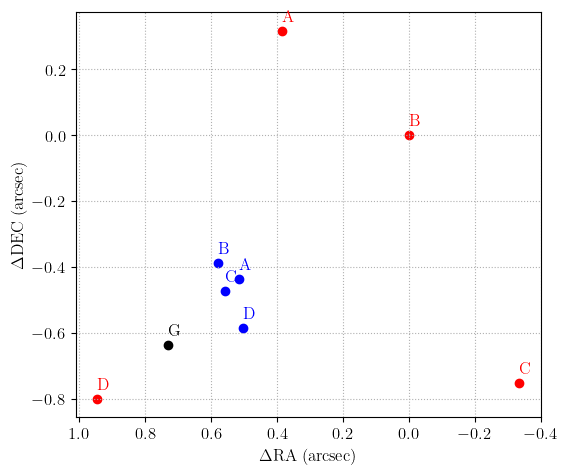

In [35]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');


## Fit with floating lens parameters, fixed shear

5 free parameters: theta_E, e1, e2, theta_lens (2)

In [69]:
lensEquationSolver = LensEquationSolver(lens_model) # initialize class for lens equation solver
solver4Point = Solver4Point(lensModel=lens_model, solver_type='PROFILE') # initialize class for 4-image lens model solver, fixed shear
kwargs_lens_init = copy.deepcopy(kwargs_lens) # take as initial guess the Cosmograil solution
print('kwargs_lens_init: \n', kwargs_lens_init)

kwargs_lens_init: 
 [{'theta_E': 0.771, 'e1': -0.11352899513903059, 'e2': -0.2559514939646221, 'center_x': 0.7321, 'center_y': -0.639}, {'gamma1': -0.044741106008917134, 'gamma2': 0.1681494378019113}]


In [70]:
# solve for lens model parameters that satisfy the 4-image constraints
kwargs_lens_fit, precision = solver4Point.constraint_lensmodel(x_pos=theta[:,0], y_pos=theta[:,1], 
                                                               kwargs_list=kwargs_lens_init, xtol=1e-12)
print('kwargs_lens_fit: \n', kwargs_lens_fit)

kwargs_lens_fit: 
 [{'theta_E': 0.776260755455916, 'e1': 0.06509412017886437, 'e2': -0.14697342120583357, 'center_x': 0.7281005110145559, 'center_y': -0.6503824875321547}, {'gamma1': -0.044741106008917134, 'gamma2': 0.1681494378019113}]


/Users/kvantilburg/anaconda3/envs/quasar-lens/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:177: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


In [71]:
theta_lens_fit = np.asarray([kwargs_lens_fit[0]['center_x'],kwargs_lens_fit[0]['center_y']]) # best-fit lens galaxy location
beta_new = np.transpose(lens_model.ray_shooting(theta[:4,0], theta[:4,1], kwargs_lens_fit)) # best-fit source plane coordinates of images
beta_fit = np.mean(beta_new,axis=0) # best-fit source plane coordinate of quasar
print('theta_lens_fit: \n', theta_lens_fit)
print('beta_new: \n', beta_new)
print('beta_fit: \n', beta_fit)

theta_lens_fit: 
 [ 0.72810051 -0.65038249]
beta_new: 
 [[ 0.52671285 -0.50720816]
 [ 0.52672567 -0.5072982 ]
 [ 0.52691308 -0.50736986]
 [ 0.52675307 -0.50714268]]
beta_fit: 
 [ 0.52677617 -0.50725473]


In [72]:
# solve for the new image positions (which should come very close to the true ones)
lens_equation_solver_fit = LensEquationSolver(lensModel=lens_model)
theta_fit = np.transpose(lens_equation_solver_fit.image_position_from_source(kwargs_lens=kwargs_lens_fit, 
                                                                             sourcePos_x=beta_fit[0], sourcePos_y=beta_fit[1], 
                                                                             min_distance=0.001, search_window=5, 
                                                                             precision_limit=1e-10, num_iter_max=200))

# sort best-fit image positions to their closest true image position
distances = np.zeros((len(theta_fit),len(theta)))
for i, point_fit in enumerate(theta_fit):
    for j, point in enumerate(theta):
        distances[i,j] = np.linalg.norm(point_fit-point) # euclidean distance between the true and best-fit image positions
closest_indices = np.argmin(distances, axis=1)
theta_fit = theta_fit[np.argsort(closest_indices)] # Sort theta_fit based on the index of the closest point in theta

# print('distances: \n', distances) # distances between true and best-fit image positions
# print(closest_indices)
print('theta: \n', theta) # true image positions
print('theta_fit: \n', theta_fit) # image positions given best-fit lens model and source location

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_fit: 
 [[ 3.86246611e-01  3.16962678e-01]
 [-4.30402489e-04 -5.15211414e-04]
 [-3.36087228e-01 -7.51132287e-01]
 [ 9.47075309e-01 -8.01215585e-01]]


In [73]:
mag = lens_model.magnification(theta[:,0], theta[:,1], kwargs_lens_fit) # magnification of true image positions given best-fit lens model
mag_fit = lens_model.magnification(theta_fit[:,0], theta_fit[:,1], kwargs_lens_fit) # magnification of best-fit image positions given best-fit lens model
print('mag: \n', mag) 
print('mag_fit: \n', mag_fit) 

mag: 
 [ 6.85514628 -8.69624752  4.41193765 -0.32705635]
mag_fit: 
 [ 6.84992009 -8.68443701  4.41569408 -0.32717149]


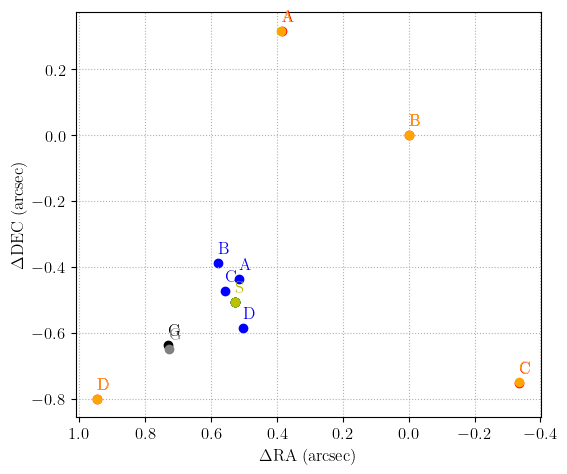

In [74]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')
    ax.scatter(beta_new[i,0],beta_new[i,1],color='g',label=labels[i])
    #ax.text(beta_new[i,0],beta_new[i,1]+0.02,labels[i],color='g',ha='left',va='bottom')

ax.scatter(beta_fit[0],beta_fit[1],color='y')
ax.text(beta_fit[0],beta_fit[1]+0.02,'S',color='y',ha='left',va='bottom')
for i in range(len(theta_fit)):
    ax.scatter(theta_fit[i,0],theta_fit[i,1],color='orange',label=labels[i])
    ax.text(theta_fit[i,0],theta_fit[i,1]+0.02,labels[i],color='orange',ha='left',va='bottom')

ax.scatter(theta_lens_fit[0],theta_lens_fit[1],color='gray')
ax.text(theta_lens_fit[0],theta_lens_fit[1]+0.02,'G',color='gray',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');

# Fit with floating lens parameters and shear

7 free parameters: theta_E, e1, e2, theta_lens (2), gamma1, gamma2

In [75]:
lensEquationSolver = LensEquationSolver(lens_model) # initialize class for lens equation solver
solver4Point = Solver4Point(lensModel=lens_model, solver_type='PROFILE_SHEAR') # initialize class for 4-image lens model solver, fixed shear
kwargs_lens_init = copy.deepcopy(kwargs_lens_fit) # take as initial guess the previous fit
print('kwargs_lens_init: \n', kwargs_lens_init)

kwargs_lens_init: 
 [{'theta_E': 0.776260755455916, 'e1': 0.06509412017886437, 'e2': -0.14697342120583357, 'center_x': 0.7281005110145559, 'center_y': -0.6503824875321547}, {'gamma1': -0.044741106008917134, 'gamma2': 0.1681494378019113}]


In [76]:
# solve for lens model parameters that satisfy the 4-image constraints
kwargs_lens_fit, precision = solver4Point.constraint_lensmodel(x_pos=theta[:,0], y_pos=theta[:,1], 
                                                               kwargs_list=kwargs_lens_init, xtol=1e-14)
print('kwargs_lens_fit: \n', kwargs_lens_fit)

kwargs_lens_fit: 
 [{'theta_E': 0.7761938936468246, 'e1': 0.06470746299724082, 'e2': -0.14701338954709725, 'center_x': 0.7279119221696818, 'center_y': -0.6503046841699268}, {'gamma1': -0.0450419445133418, 'gamma2': 0.16806910255742138}]


In [77]:
theta_lens_fit = np.asarray([kwargs_lens_fit[0]['center_x'],kwargs_lens_fit[0]['center_y']]) # best-fit lens galaxy location
beta_new = np.transpose(lens_model.ray_shooting(theta[:4,0], theta[:4,1], kwargs_lens_fit)) # best-fit source plane coordinates of images
beta_fit = np.mean(beta_new,axis=0) # best-fit source plane coordinate of quasar
print('theta_lens_fit: \n', theta_lens_fit)
print('beta_new: \n', beta_new)
print('beta_fit: \n', beta_fit)

theta_lens_fit: 
 [ 0.72791192 -0.65030468]
beta_new: 
 [[ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]
 [ 0.52679096 -0.50714071]]
beta_fit: 
 [ 0.52679096 -0.50714071]


In [78]:
# solve for the new image positions (which should come very close to the true ones)
lens_equation_solver_fit = LensEquationSolver(lensModel=lens_model)
theta_fit = np.transpose(lens_equation_solver_fit.image_position_from_source(kwargs_lens=kwargs_lens_fit, 
                                                                             sourcePos_x=beta_fit[0], sourcePos_y=beta_fit[1], 
                                                                             min_distance=0.001, search_window=5, 
                                                                             precision_limit=1e-10, num_iter_max=200))

# sort best-fit image positions to their closest true image position
distances = np.zeros((len(theta_fit),len(theta)))
for i, point_fit in enumerate(theta_fit):
    for j, point in enumerate(theta):
        distances[i,j] = np.linalg.norm(point_fit-point) # euclidean distance between the true and best-fit image positions
closest_indices = np.argmin(distances, axis=1)
theta_fit = theta_fit[np.argsort(closest_indices)] # Sort theta_fit based on the index of the closest point in theta

# print('distances: \n', distances) # distances between true and best-fit image positions
# print(closest_indices)
print('theta: \n', theta) # true image positions
print('theta_fit: \n', theta_fit) # image positions given best-fit lens model and source location

theta: 
 [[ 0.386   0.3169]
 [ 0.      0.    ]
 [-0.336  -0.7516]
 [ 0.947  -0.8012]]
theta_fit: 
 [[ 3.86000000e-01  3.16900000e-01]
 [-1.95484782e-12 -2.79422925e-12]
 [-3.36000000e-01 -7.51600000e-01]
 [ 9.47000000e-01 -8.01200000e-01]]


In [83]:
mag = lens_model.magnification(theta[:,0], theta[:,1], kwargs_lens_fit) # magnification of true image positions given best-fit lens model
mag_fit = lens_model.magnification(theta_fit[:,0], theta_fit[:,1], kwargs_lens_fit) # magnification of best-fit image positions given best-fit lens model
flux_ratios_fit = np.abs(mag_fit[:]/mag_fit[0]) # flux ratios of best-fit image positions (relative to image A)
print('mag: \n', mag) 
print('mag_fit: \n', mag_fit) 
print('flux_ratios: \n', flux_ratios)
print('flux_ratios_fit: \n', flux_ratios_fit)

mag: 
 [ 6.85806851 -8.6880414   4.41141542 -0.32744648]
mag_fit: 
 [ 6.85805545 -8.68799619  4.4114407  -0.32744648]
flux_ratios: 
 [1.    1.116 0.59  0.032]
flux_ratios_fit: 
 [1.         1.26683085 0.64324949 0.04774626]


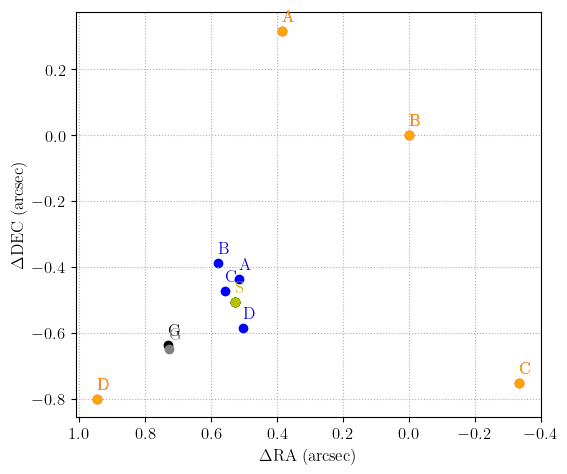

In [84]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.scatter(theta_lens[0],theta_lens[1],color='k',label='G')
ax.text(theta_lens[0],theta_lens[1]+0.02,'G',color='k',ha='left',va='bottom')

for i in range(len(theta)):
    ax.scatter(theta[i,0],theta[i,1],color='r',label=labels[i])
    ax.text(theta[i,0],theta[i,1]+0.02,labels[i],color='r',ha='left',va='bottom')
    ax.scatter(beta[i,0],beta[i,1],color='b',label=labels[i])
    ax.text(beta[i,0],beta[i,1]+0.02,labels[i],color='b',ha='left',va='bottom')
    ax.scatter(beta_new[i,0],beta_new[i,1],color='g',label=labels[i])
    #ax.text(beta_new[i,0],beta_new[i,1]+0.02,labels[i],color='g',ha='left',va='bottom')

ax.scatter(beta_fit[0],beta_fit[1],color='y')
ax.text(beta_fit[0],beta_fit[1]+0.02,'S',color='y',ha='left',va='bottom')
for i in range(len(theta_fit)):
    ax.scatter(theta_fit[i,0],theta_fit[i,1],color='orange',label=labels[i])
    ax.text(theta_fit[i,0],theta_fit[i,1]+0.02,labels[i],color='orange',ha='left',va='bottom')

ax.scatter(theta_lens_fit[0],theta_lens_fit[1],color='gray')
ax.text(theta_lens_fit[0],theta_lens_fit[1]+0.02,'G',color='gray',ha='left',va='bottom')

ax.invert_xaxis()
ax.set_aspect('equal')
ax.grid(ls='dotted')
ax.set_xlabel(r'$\Delta \mathrm{RA}$ (arcsec)');
ax.set_ylabel(r'$\Delta \mathrm{DEC}$ (arcsec)');